# HATR BSD10k Colab 5-Fold Training

이 노트북은 `https://github.com/allholy/hatr.git`의 HATR 코드를 Colab에서 실행하도록 구성합니다.

- metadata: `/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv`
- audio embeddings: `/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings`
- text embeddings: `/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings`
- `confidence == 1` 샘플은 train/validation/test 전체에서 제외하되, `sp-c`, `sp-p`, `fx-v`, `fx-m`, `fx-a` class는 유지합니다.
- 마지막 셀에서 fold별 confusion matrix의 평균과 표준편차를 `mean ± std` 형태로 확인합니다.


In [1]:
# 1. Drive mount, package install, HATR clone
from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess
import sys

!pip -q install numpy pandas scikit-learn matplotlib seaborn PyYAML tqdm

REPO_URL = "https://github.com/allholy/hatr.git"
HATR_DIR = "/content/hatr"

if not os.path.isdir(HATR_DIR):
    subprocess.run(["git", "clone", REPO_URL, HATR_DIR], check=True)
else:
    print(f"HATR repo already exists: {HATR_DIR}")

if HATR_DIR not in sys.path:
    sys.path.insert(0, HATR_DIR)

print("HATR_DIR:", HATR_DIR)


Mounted at /content/drive
HATR_DIR: /content/hatr


In [2]:
# 2. Dataset paths and experiment settings
import json
import random
import shutil
import subprocess
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

METADATA_CSV = "/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv"
DRIVE_AUDIO_EMB_DIR = "/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings"
DRIVE_TEXT_EMB_DIR  = "/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings"

# Copy Drive embeddings to Colab local disk first. Direct per-batch np.load from Drive is very slow.
LOCAL_BASE_DIR = "/content/bsd10k_features_hatr"
AUDIO_EMB_DIR = f"{LOCAL_BASE_DIR}/clap_audio_embeddings"
TEXT_EMB_DIR = f"{LOCAL_BASE_DIR}/clap_text_embeddings"

PROJECT_DIR = "/content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab_no_conf1"
OUTPUT_DATA_DIR = f"{PROJECT_DIR}/data"
MODEL_OUTPUT_DIR = f"{PROJECT_DIR}/model_output"
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

SEED = 1821
N_FOLDS = 5
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
PATIENCE = 5
EARLY_STOPPING_FACTOR = 3  # dcase2026_task1_baseline/train_test.py __main__ setting
MODE = "both"  # "audio", "text", or "both"
EXCLUDE_CONFIDENCE_VALUES = [1]  # train/validation/test 전체에서 제외할 confidence 값
KEEP_CONFIDENCE1_CLASSES = ["sp-c", "sp-p", "fx-v", "fx-m", "fx-a"]  # confidence 1이어도 유지할 class

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
def copy_one_feature_dir(src, dst, retries=3):
    src = Path(src)
    dst = Path(dst)
    dst.mkdir(parents=True, exist_ok=True)

    existing = len(list(dst.glob("*.npy")))
    if existing > 0:
        print(f"Already has {existing:,} npy files: {dst}")

    last_error = None
    for attempt in range(1, retries + 1):
        try:
            if not src.exists():
                raise FileNotFoundError(f"Drive source folder does not exist or is not mounted: {src}")
            files = sorted(src.glob("*.npy"))
            if len(files) == 0:
                parent_items = []
                try:
                    parent_items = [p.name for p in src.parent.iterdir()][:20]
                except Exception:
                    parent_items = []
                raise RuntimeError(
                    f"No .npy files found in {src}. Google Drive is likely not mounted/visible, "
                    f"or the path is wrong. Parent folder sample: {parent_items}"
                )
            print(f"Copying {len(files):,} files: {src} -> {dst} (attempt {attempt}/{retries})")
            copied = 0
            skipped = 0
            for file_path in files:
                out_path = dst / file_path.name
                if out_path.exists() and out_path.stat().st_size == file_path.stat().st_size:
                    skipped += 1
                    continue
                shutil.copy2(file_path, out_path)
                copied += 1
                if copied % 1000 == 0:
                    print(f"  copied {copied:,}, skipped {skipped:,}")
            print(f"Done: copied {copied:,}, skipped {skipped:,}, total local {len(list(dst.glob('*.npy'))):,}")
            return
        except (OSError, ConnectionError, RuntimeError) as exc:
            last_error = exc
            print(f"Copy failed on attempt {attempt}: {repr(exc)}")
            if attempt < retries:
                print("Waiting 10 seconds before retry. If this repeats, remount Drive and rerun this cell.")
                time.sleep(10)
    raise RuntimeError(f"Failed to copy {src} after {retries} attempts. Remount Google Drive and rerun this cell.") from last_error

def copy_drive_features_to_local():
    Path(LOCAL_BASE_DIR).mkdir(parents=True, exist_ok=True)
    copy_one_feature_dir(DRIVE_AUDIO_EMB_DIR, AUDIO_EMB_DIR)
    copy_one_feature_dir(DRIVE_TEXT_EMB_DIR, TEXT_EMB_DIR)

print("Output:", PROJECT_DIR)


Output: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab_no_conf1


In [3]:
# 3. Write HATR config.yaml for Colab paths
config = {
    "active_dataset": "BSD10k-v1.2",
    "datasets": {
        "BSD10k-v1.2": {
            "metadata_csv": METADATA_CSV,
            "audio_emb_folder": AUDIO_EMB_DIR,
            "text_emb_folder": TEXT_EMB_DIR,
            "class_names": "",
        }
    },
    "color_dict_path": f"{HATR_DIR}/data/bst_colours.json",
    "top_color_dict_path": f"{HATR_DIR}/data/bst_colours.json",
    "output_path": OUTPUT_DATA_DIR,
    "processed_dataset_csv": "processed_dataset.csv",
    "class_dict_json": "class_dict.json",
    "top_class_dict_json": "top_class_dict.json",
    "top_class_subclass_dict_json": "top_class_subclass_dict.json",
}

with open(f"{HATR_DIR}/config.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=False, allow_unicode=True)

print(open(f"{HATR_DIR}/config.yaml", encoding="utf-8").read())


active_dataset: BSD10k-v1.2
datasets:
  BSD10k-v1.2:
    metadata_csv: /content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv
    audio_emb_folder: /content/bsd10k_features_hatr/clap_audio_embeddings
    text_emb_folder: /content/bsd10k_features_hatr/clap_text_embeddings
    class_names: ''
color_dict_path: /content/hatr/data/bst_colours.json
top_color_dict_path: /content/hatr/data/bst_colours.json
output_path: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab_no_conf1/data
processed_dataset_csv: processed_dataset.csv
class_dict_json: class_dict.json
top_class_dict_json: top_class_dict.json
top_class_subclass_dict_json: top_class_subclass_dict.json



In [4]:
# 4. Build processed HATR dataset from metadata + .npy embeddings
import subprocess
import sys

copy_drive_features_to_local()

subprocess.run([sys.executable, "build_dataset_full.py"], cwd=HATR_DIR, check=True)

PROCESSED_CSV = f"{OUTPUT_DATA_DIR}/processed_dataset.csv"
CLASS_DICT_JSON = f"{OUTPUT_DATA_DIR}/class_dict.json"
TOP_CLASS_DICT_JSON = f"{OUTPUT_DATA_DIR}/top_class_dict.json"

full_df = pd.read_csv(PROCESSED_CSV)
metadata_df = pd.read_csv(METADATA_CSV)

full_df["index"] = full_df["index"].astype(str)
metadata_df["sound_id"] = metadata_df["sound_id"].astype(str)

if EXCLUDE_CONFIDENCE_VALUES and "confidence" in metadata_df.columns:
    before_rows = len(full_df)
    keep_conf1_classes = set(KEEP_CONFIDENCE1_CLASSES)
    exclude_mask = metadata_df["confidence"].isin(EXCLUDE_CONFIDENCE_VALUES)
    if "class" in metadata_df.columns and keep_conf1_classes:
        exclude_mask = exclude_mask & ~metadata_df["class"].isin(keep_conf1_classes)
    excluded_ids = set(metadata_df.loc[exclude_mask, "sound_id"])
    full_df = full_df[~full_df["index"].isin(excluded_ids)].reset_index(drop=True)
    print(f"Excluded confidence values {EXCLUDE_CONFIDENCE_VALUES}, except classes {KEEP_CONFIDENCE1_CLASSES}: {before_rows - len(full_df)} rows")
    if "class" in metadata_df.columns:
        kept_exception_ids = set(metadata_df.loc[metadata_df["confidence"].isin(EXCLUDE_CONFIDENCE_VALUES) & metadata_df["class"].isin(keep_conf1_classes), "sound_id"])
        print(f"Kept confidence-1 exception rows: {full_df['index'].isin(kept_exception_ids).sum()}")

print("Processed rows:", len(full_df))
print("Classes:", full_df["class_idx"].nunique())
display(full_df.head())


Copying 10,956 files: /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings -> /content/bsd10k_features_hatr/clap_audio_embeddings (attempt 1/3)
  copied 1,000, skipped 0
  copied 2,000, skipped 0
  copied 3,000, skipped 0
  copied 4,000, skipped 0
  copied 5,000, skipped 0
  copied 6,000, skipped 0
  copied 7,000, skipped 0
  copied 8,000, skipped 0
  copied 9,000, skipped 0
  copied 10,000, skipped 0
Done: copied 10,956, skipped 0, total local 10,956
Copying 10,972 files: /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings -> /content/bsd10k_features_hatr/clap_text_embeddings (attempt 1/3)
  copied 1,000, skipped 0
  copied 2,000, skipped 0
  copied 3,000, skipped 0
  copied 4,000, skipped 0
  copied 5,000, skipped 0
  copied 6,000, skipped 0
  copied 7,000, skipped 0
  copied 8,000, skipped 0
  copied 9,000, skipped 0
  copied 10,000, skipped 0
Done: copied 10,972, skipped 0, total local 10,972
Excluded confidence values [1], except classes ['sp-c', 's

,index,audio_emb_filepath,text_emb_filepath,top_class,top_class_idx,class,class_idx
0,185755,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,fx,3,fx-o,11
1,358405,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,is,1,is-w,5
2,358760,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,is,1,is-w,5
3,432206,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,fx,3,fx-o,11
4,80630,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,sp,2,sp-s,8


In [5]:
# 5. Imports and HATR helper functions
import collections
from collections import defaultdict

import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dataset_utils import HATRDataset
from losses import CrossEntropyLoss, HierarchicalContrastiveLoss, TopClassLoss
from models import BaseClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

with open(CLASS_DICT_JSON, encoding="utf-8") as f:
    class_dict = json.load(f)
with open(TOP_CLASS_DICT_JSON, encoding="utf-8") as f:
    top_class_dict = json.load(f)

id_to_class = {int(v): k for k, v in class_dict.items()}
class_names = [id_to_class[i] for i in range(len(id_to_class))]

def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

def build_class_to_top_class_mapping(class_dict, top_class_dict):
    class_to_top = {}
    for class_name, class_id in class_dict.items():
        top_name = class_name.split("-")[0]
        class_to_top[int(class_id)] = int(top_class_dict[top_name])
    return class_to_top

def build_subclass_to_topclass_tensor(class_dict, top_class_dict, device):
    class_to_top = build_class_to_top_class_mapping(class_dict, top_class_dict)
    tensor = torch.zeros(len(class_dict), dtype=torch.long, device=device)
    for class_id, top_id in class_to_top.items():
        tensor[class_id] = top_id
    return tensor

class_to_top_class = build_class_to_top_class_mapping(class_dict, top_class_dict)
subclass_to_topclass = build_subclass_to_topclass_tensor(class_dict, top_class_dict, device)


Device: cuda


In [6]:
# 6. Train/evaluate functions
def make_loaders(train_df, val_df, test_df):
    train_ds = HATRDataset(train_df, aug=True, mask_pct=0.7)
    val_ds = HATRDataset(val_df, aug=False)
    test_ds = HATRDataset(test_df, aug=False)
    # Colab + Drive/local npy loading is more stable with num_workers=0.
    common = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, val_loader, test_loader

def make_model():
    emb_size_audio = 512 if MODE in ["audio", "both"] else 0
    emb_size_text = 512 if MODE in ["text", "both"] else 0
    model = BaseClassifier(
        hidden_size=128,
        num_classes=len(class_dict),
        emb_size_audio=emb_size_audio,
        emb_size_text=emb_size_text,
        dropout=0.1,
        use_batch_norm=True,
        mode=MODE,
    ).to(device)
    model.apply(init_weights)
    return model

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    ce_loss = CrossEntropyLoss()
    top_loss = TopClassLoss(class_to_top_class, penalty_weight=1.0)
    contrastive_loss = HierarchicalContrastiveLoss(subclass_to_topclass=subclass_to_topclass)
    total_loss = 0.0
    y_true, y_pred = [], []

    for batch in loader:
        labels = batch["class_idx"].long().to(device)
        audio = batch.get("audio_embedding")
        text = batch.get("text_embedding")
        audio = audio.to(device) if audio is not None else None
        text = text.to(device) if text is not None else None

        with torch.set_grad_enabled(is_train):
            z, logits, _ = model(audio, text)
            loss = ce_loss(logits, labels)
            loss = loss + 1.0 * top_loss(logits, labels)
            loss = loss + 0.3 * contrastive_loss(z, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += float(loss.detach().cpu()) * labels.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(y_true))
    acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    return avg_loss, acc, np.array(y_true), np.array(y_pred)

def extend_subcat(label_name):
    parts = str(label_name).split("-")
    top = parts[0]
    sub = "-".join(parts[1:]) if len(parts) > 1 else ""
    return [top, sub]

def get_top_level(label_name):
    return str(label_name).split("-")[0]

def hierarchical_accuracy_for_class(subcat, prediction_gt_pairs, lambda_param=0.5):
    scores = []
    for prediction, gt in prediction_gt_pairs:
        if subcat == gt:
            pred_top, pred_sub = extend_subcat(prediction)
            gt_top, gt_sub = extend_subcat(gt)
            if pred_top == gt_top and pred_sub == gt_sub:
                scores.append(1.0)
            elif pred_top == gt_top and pred_sub != gt_sub:
                scores.append(lambda_param)
            else:
                scores.append(0.0)
    return np.mean(scores) if scores else np.nan

def hierarchical_prf_weighted_for_class(subcat, prediction_gt_pairs, lambda_param=0.75):
    hPP, hRR = [], []
    for prediction, gt in prediction_gt_pairs:
        pi = extend_subcat(prediction)
        ti = extend_subcat(gt)
        overlap = len(set(pi).intersection(set(ti)))
        if subcat == prediction:
            w = 1.0 if prediction == gt else (lambda_param if get_top_level(prediction) == get_top_level(gt) else 0.0)
            hPP.append((w * overlap) / len(pi))
        if subcat == gt:
            w = 1.0 if prediction == gt else (lambda_param if get_top_level(prediction) == get_top_level(gt) else 0.0)
            hRR.append((w * overlap) / len(ti))
    classP = np.mean(hPP) if hPP else np.nan
    classR = np.mean(hRR) if hRR else np.nan
    if np.isnan(classP) or np.isnan(classR):
        classF = np.nan
    elif classP == 0 and classR == 0:
        classF = 0.0
    else:
        classF = 2 * classP * classR / (classP + classR)
    return classP, classR, classF

def compute_baseline_style_metrics(y_true, y_pred):
    y_true = [int(x) for x in y_true]
    y_pred = [int(x) for x in y_pred]
    gt_labels = [id_to_class[x] for x in y_true]
    pred_labels = [id_to_class[x] for x in y_pred]
    prediction_gt_pairs = list(zip(pred_labels, gt_labels))
    classes = sorted(set(gt_labels))

    accuracy = np.mean(np.array(y_true) == np.array(y_pred))
    top_accuracy = np.mean([class_to_top_class.get(gt) == class_to_top_class.get(pred) for gt, pred in zip(y_true, y_pred)])

    class_accs, class_top_accs = [], []
    for c in sorted(set(y_true)):
        idx = [i for i, gt in enumerate(y_true) if gt == c]
        class_accs.append(np.mean([y_pred[i] == y_true[i] for i in idx]))
        class_top_accs.append(np.mean([class_to_top_class.get(y_true[i]) == class_to_top_class.get(y_pred[i]) for i in idx]))

    h_accs, hPs, hRs, hFs = [], [], [], []
    for c in classes:
        h_acc = hierarchical_accuracy_for_class(c, prediction_gt_pairs, lambda_param=0.5)
        if not np.isnan(h_acc):
            h_accs.append(h_acc)
        hP, hR, hF = hierarchical_prf_weighted_for_class(c, prediction_gt_pairs, lambda_param=0.75)
        if not np.isnan(hP):
            hPs.append(hP)
        if not np.isnan(hR):
            hRs.append(hR)
        if not np.isnan(hF):
            hFs.append(hF)

    return {
        "accuracy": 100 * accuracy,
        "top_accuracy": 100 * top_accuracy,
        "macro_accuracy": 100 * np.mean(class_accs),
        "macro_top_accuracy": 100 * np.mean(class_top_accs),
        "hierarchical_accuracy": 100 * np.mean(h_accs),
        "hierarchical_precision": 100 * np.mean(hPs),
        "hierarchical_recall": 100 * np.mean(hRs),
        "hierarchical_f1": 100 * np.mean(hFs),
    }

def train_one_fold(fold, train_df, val_df, test_df):
    fold_dir = f"{MODEL_OUTPUT_DIR}/fold_{fold}"
    os.makedirs(fold_dir, exist_ok=True)
    best_path = f"{fold_dir}/best_model.pth"

    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    best_val_acc = -1.0
    stale_epochs = 0
    history = []

    for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc=f"Fold {fold}"):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, optimizer=None)
        scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            stale_epochs = 0
            torch.save(model.state_dict(), best_path)
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % 5 == 0:
            print(f"fold={fold} epoch={epoch:03d} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        if stale_epochs >= PATIENCE * EARLY_STOPPING_FACTOR:
            print(f"Fold {fold}: early stopping at epoch {epoch}")
            break

    pd.DataFrame(history).to_csv(f"{fold_dir}/history.csv", index=False)
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader, optimizer=None)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_dict))))
    np.save(f"{fold_dir}/confusion_matrix.npy", cm)
    pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(f"{fold_dir}/predictions.csv", index=False)

    metrics = compute_baseline_style_metrics(y_true, y_pred)
    pd.DataFrame([metrics]).to_csv(f"{fold_dir}/baseline_style_metrics.csv", index=False)

    print(f"Fold {fold} done: best_val_acc={best_val_acc:.4f}, test_acc={test_acc:.4f}")
    print("  " + " | ".join([f"{k}={v:.2f}%" for k, v in metrics.items() if k in ["accuracy", "top_accuracy", "hierarchical_accuracy", "hierarchical_f1"]]))
    return {"fold": fold, "best_val_acc": best_val_acc, "test_acc": test_acc, "cm": cm, **metrics}


In [7]:
# 7. Run stratified K-fold training
labels = full_df["class_idx"].astype(int).to_numpy()
class_counts = pd.Series(labels).value_counts()
effective_folds = N_FOLDS

if int(class_counts.min()) < N_FOLDS:
    raise ValueError(f"The rarest class has only {int(class_counts.min())} samples, but baseline-style StratifiedKFold needs {N_FOLDS} folds.")

skf = StratifiedKFold(n_splits=effective_folds, shuffle=True, random_state=SEED)
fold_results = []

for fold, (trainval_idx, test_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
    trainval_labels = labels[trainval_idx]
    # Match dcase2026_task1_baseline/train_test.py exactly: fixed 20% validation split and fixed seed.
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_rel, val_rel = next(sss.split(np.zeros(len(trainval_labels)), trainval_labels))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel]

    train_df = full_df.iloc[train_idx].reset_index(drop=True)
    val_df = full_df.iloc[val_idx].reset_index(drop=True)
    test_df = full_df.iloc[test_idx].reset_index(drop=True)

    print(f"\n==== Fold {fold}/{effective_folds} ====")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    fold_results.append(train_one_fold(fold, train_df, val_df, test_df))

summary = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in fold_results])
summary.to_csv(f"{MODEL_OUTPUT_DIR}/fold_summary.csv", index=False)
display(summary)

SUMMARY_METRICS = [
    "accuracy",
    "top_accuracy",
    "macro_accuracy",
    "macro_top_accuracy",
    "hierarchical_accuracy",
    "hierarchical_precision",
    "hierarchical_recall",
    "hierarchical_f1",
]

metric_mean_std = pd.DataFrame({
    "mean": summary[SUMMARY_METRICS].mean(),
    "std": summary[SUMMARY_METRICS].std(ddof=0),
})
metric_mean_std["mean_pm_std"] = metric_mean_std.apply(lambda r: f"{r['mean']:.2f}% ± {r['std']:.2f}%", axis=1)
metric_mean_std.to_csv(f"{MODEL_OUTPUT_DIR}/baseline_style_metrics_mean_std.csv")
display(metric_mean_std)



==== Fold 1/5 ====
Train: 6954, Val: 1739, Test: 2174


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

fold=1 epoch=001 train_acc=0.2520 val_acc=0.5273
fold=1 epoch=005 train_acc=0.7166 val_acc=0.7470
fold=1 epoch=010 train_acc=0.7933 val_acc=0.7941
fold=1 epoch=015 train_acc=0.8194 val_acc=0.7798
fold=1 epoch=020 train_acc=0.8396 val_acc=0.7849
fold=1 epoch=025 train_acc=0.8825 val_acc=0.8005
fold=1 epoch=030 train_acc=0.8911 val_acc=0.7993
fold=1 epoch=035 train_acc=0.9026 val_acc=0.7936
Fold 1: early stopping at epoch 36
Fold 1 done: best_val_acc=0.8085, test_acc=0.8068
  accuracy=80.68% | top_accuracy=90.25% | hierarchical_accuracy=79.79% | hierarchical_f1=77.49%

==== Fold 2/5 ====
Train: 6954, Val: 1739, Test: 2174


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

fold=2 epoch=001 train_acc=0.2857 val_acc=0.6090
fold=2 epoch=005 train_acc=0.7257 val_acc=0.7792
fold=2 epoch=010 train_acc=0.7869 val_acc=0.7826
fold=2 epoch=015 train_acc=0.8265 val_acc=0.7890
fold=2 epoch=020 train_acc=0.8390 val_acc=0.7941
fold=2 epoch=025 train_acc=0.8856 val_acc=0.7918
fold=2 epoch=030 train_acc=0.8905 val_acc=0.7941
fold=2 epoch=035 train_acc=0.9036 val_acc=0.7890
Fold 2: early stopping at epoch 38
Fold 2 done: best_val_acc=0.8120, test_acc=0.8100
  accuracy=81.00% | top_accuracy=89.79% | hierarchical_accuracy=80.25% | hierarchical_f1=78.28%

==== Fold 3/5 ====
Train: 6955, Val: 1739, Test: 2173


...

fold=4 epoch=001 train_acc=0.2729 val_acc=0.5572
fold=4 epoch=005 train_acc=0.7297 val_acc=0.7608
fold=4 epoch=010 train_acc=0.7943 val_acc=0.7861
fold=4 epoch=015 train_acc=0.8229 val_acc=0.7924
fold=4 epoch=020 train_acc=0.8458 val_acc=0.8033
fold=4 epoch=025 train_acc=0.8838 val_acc=0.8051
fold=4 epoch=030 train_acc=0.8973 val_acc=0.8056
fold=4 epoch=035 train_acc=0.8999 val_acc=0.7918
Fold 4: early stopping at epoch 36
Fold 4 done: best_val_acc=0.8131, test_acc=0.8256
  accuracy=82.56% | top_accuracy=90.47% | hierarchical_accuracy=81.20% | hierarchical_f1=79.30%

==== Fold 5/5 ====
Train: 6955, Val: 1739, Test: 2173


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]

fold=5 epoch=001 train_acc=0.3288 val_acc=0.6187
fold=5 epoch=005 train_acc=0.7312 val_acc=0.7763
fold=5 epoch=010 train_acc=0.8014 val_acc=0.7844
fold=5 epoch=015 train_acc=0.8325 val_acc=0.7746
fold=5 epoch=020 train_acc=0.8442 val_acc=0.8010
fold=5 epoch=025 train_acc=0.8873 val_acc=0.8028
fold=5 epoch=030 train_acc=0.8961 val_acc=0.8056
fold=5 epoch=035 train_acc=0.9015 val_acc=0.7964
fold=5 epoch=040 train_acc=0.9165 val_acc=0.7976
Fold 5: early stopping at epoch 44
Fold 5 done: best_val_acc=0.8091, test_acc=0.7869
  accuracy=78.69% | top_accuracy=88.13% | hierarchical_accuracy=79.58% | hierarchical_f1=76.44%


,fold,best_val_acc,test_acc,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1
0,1,0.808511,0.806808,80.680773,90.248390,74.474979,85.102138,79.788559,78.783656,77.101468,77.485612
1,2,0.811961,0.810028,81.002760,89.788408,75.193050,85.312833,80.252941,79.217394,77.850845,78.281127
2,3,0.805060,0.790152,79.015186,89.415555,73.335400,86.819940,80.077670,76.600688,77.020865,76.661359
3,4,0.813111,0.825587,82.558675,90.473999,76.498780,85.893161,81.195970,80.191647,78.866782,79.295067
4,5,0.809086,0.786931,78.693051,88.127013,74.593692,84.556836,79.575264,76.582985,77.005143,76.439081


,mean,std,mean_pm_std
accuracy,80.390089,1.409462,80.39% ± 1.41%
top_accuracy,89.610673,0.827396,89.61% ± 0.83%
macro_accuracy,74.819180,1.032643,74.82% ± 1.03%
macro_top_accuracy,85.536982,0.771085,85.54% ± 0.77%
hierarchical_accuracy,80.178081,0.559804,80.18% ± 0.56%
hierarchical_precision,78.275274,1.448213,78.28% ± 1.45%
hierarchical_recall,77.569020,0.721200,77.57% ± 0.72%
hierarchical_f1,77.632449,1.055821,77.63% ± 1.06%


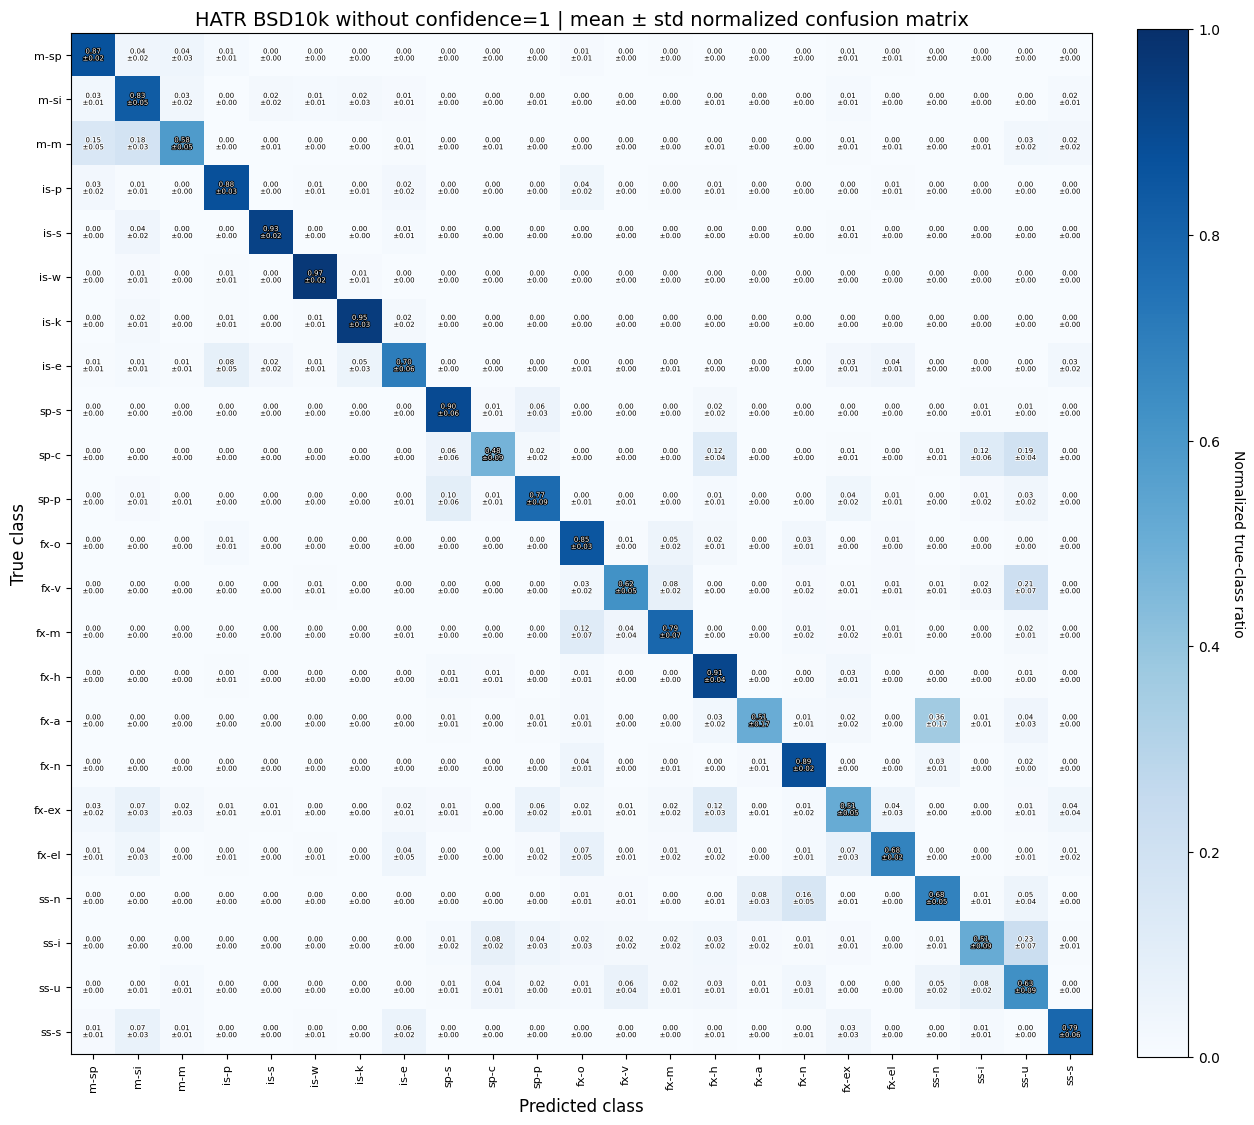

saved: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab_no_conf1/model_output/confusion_matrix_mean_pm_std_normalized_true.png


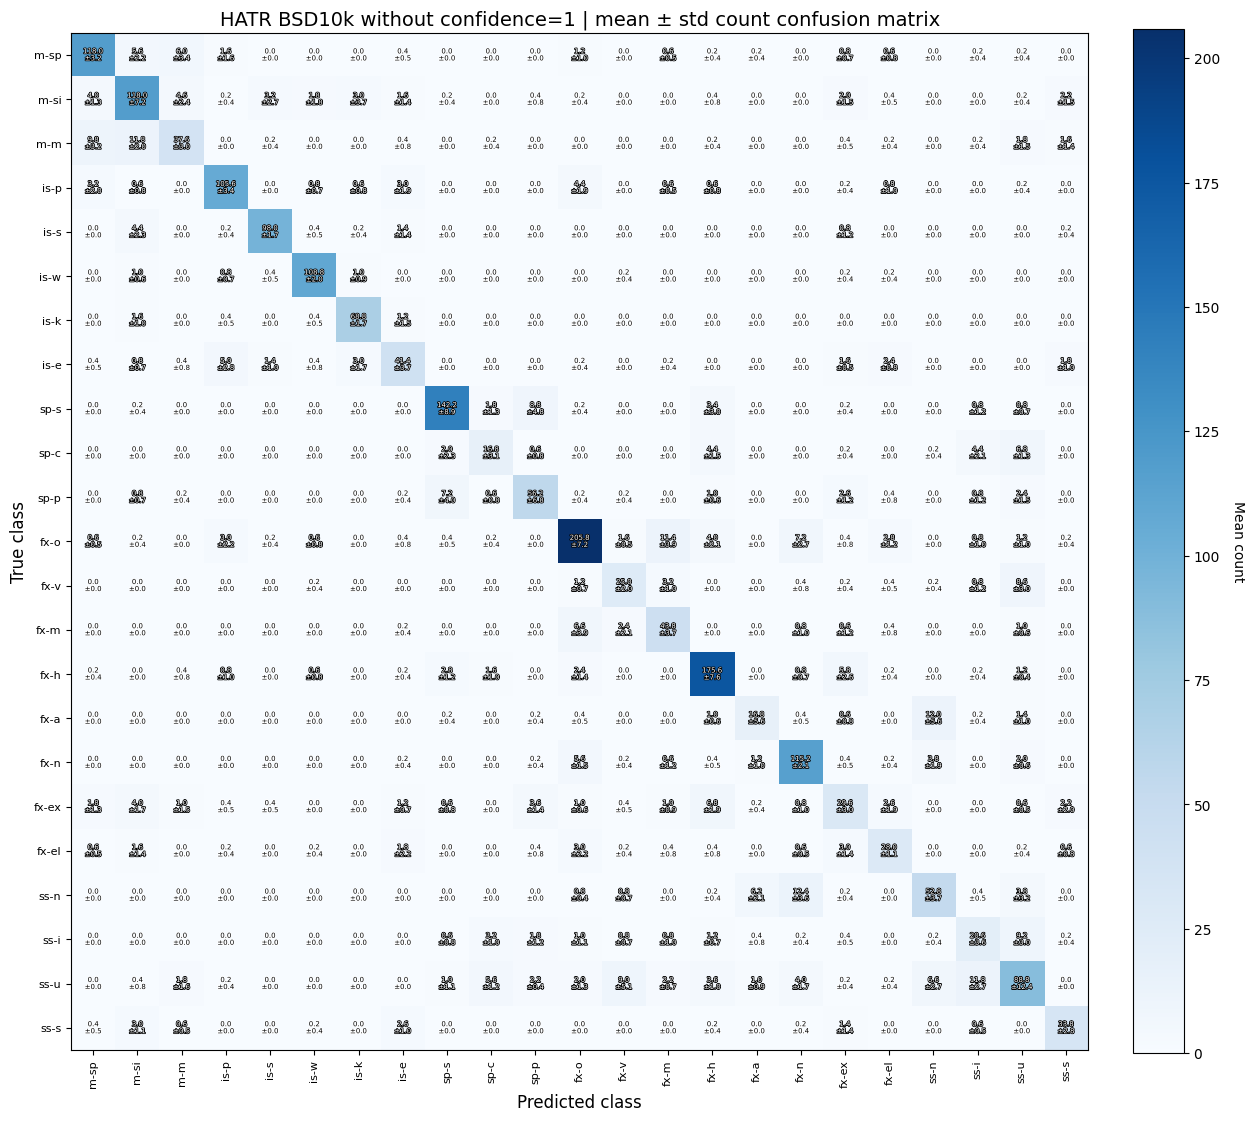

saved: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab_no_conf1/model_output/confusion_matrix_mean_pm_std_counts.png


In [8]:
# 8. Baseline-style fold mean ± std confusion matrix
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

if "fold_results" in globals() and len(fold_results) > 0:
    cms = np.stack([r["cm"] for r in fold_results], axis=0).astype(float)
else:
    cm_paths = [f"{MODEL_OUTPUT_DIR}/fold_{fold}/confusion_matrix.npy" for fold in range(1, effective_folds + 1)]
    cms = np.stack([np.load(path) for path in cm_paths], axis=0).astype(float)

cm_mean = cms.mean(axis=0)
cm_std = cms.std(axis=0, ddof=0)

row_sums = cms.sum(axis=2, keepdims=True)
cm_norms = np.divide(cms, row_sums, out=np.zeros_like(cms), where=row_sums != 0)
cm_norm_mean = cm_norms.mean(axis=0)
cm_norm_std = cm_norms.std(axis=0, ddof=0)

pd.DataFrame(cm_mean, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_mean_counts.csv")
pd.DataFrame(cm_std, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_std_counts.csv")
pd.DataFrame(cm_norm_mean, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_mean_normalized_true.csv")
pd.DataFrame(cm_norm_std, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_std_normalized_true.csv")

def annotate_mean_std_confusion_matrix(ax, mean_matrix, std_matrix, fontsize=5, value_fmt=".2f"):
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            mean_value = float(mean_matrix[i, j])
            std_value = float(std_matrix[i, j])
            text_color = "white" if mean_value >= 0.45 else "black"
            stroke_color = "black" if text_color == "white" else "white"
            text = ax.text(
                j,
                i,
                f"{mean_value:{value_fmt}}\n±{std_value:{value_fmt}}",
                ha="center",
                va="center",
                fontsize=fontsize,
                color=text_color,
            )
            text.set_path_effects([path_effects.withStroke(linewidth=1.15, foreground=stroke_color)])

def plot_baseline_style_mean_std_cm(mean_matrix, std_matrix, title, save_name, normalized=True):
    n = len(class_names)
    fig_size = max(10, n * 0.55)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    vmax = 1.0 if normalized else max(1.0, float(mean_matrix.max()))
    im = ax.imshow(mean_matrix, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=vmax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized true-class ratio" if normalized else "Mean count", rotation=270, labelpad=18)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted class", fontsize=12)
    ax.set_ylabel("True class", fontsize=12)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names, rotation=90, fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    annotate_mean_std_confusion_matrix(ax, mean_matrix, std_matrix, fontsize=5 if n > 20 else 6, value_fmt=".2f" if normalized else ".1f")
    fig.tight_layout()
    save_path = f"{MODEL_OUTPUT_DIR}/{save_name}"
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("saved:", save_path)

plot_baseline_style_mean_std_cm(
    cm_norm_mean,
    cm_norm_std,
    "HATR BSD10k without confidence=1 | mean ± std normalized confusion matrix",
    "confusion_matrix_mean_pm_std_normalized_true.png",
    normalized=True,
)

plot_baseline_style_mean_std_cm(
    cm_mean,
    cm_std,
    "HATR BSD10k without confidence=1 | mean ± std count confusion matrix",
    "confusion_matrix_mean_pm_std_counts.png",
    normalized=False,
)
